In [1]:
import sqlite3
import pandas as pd

def verificar_sistema_alerta(conn):
    query = """
    SELECT estado, quantidade, ROUND(quantidade * 0.364, 0) as meta
    FROM casos_feminicidio WHERE ano = 2025
    """
    df = pd.read_sql_query(query, conn)

    for _, row in df.iterrows():
        if row['quantidade'] > row['meta']:
            print(f"🚨 ALERTA SISTÊMICO: {row['estado']} excedeu a meta de segurança!")
            print(f"   Atual: {row['quantidade']} | Meta Alvo: {row['meta']}")

# Uso:
# verificar_sistema_alerta(conn)

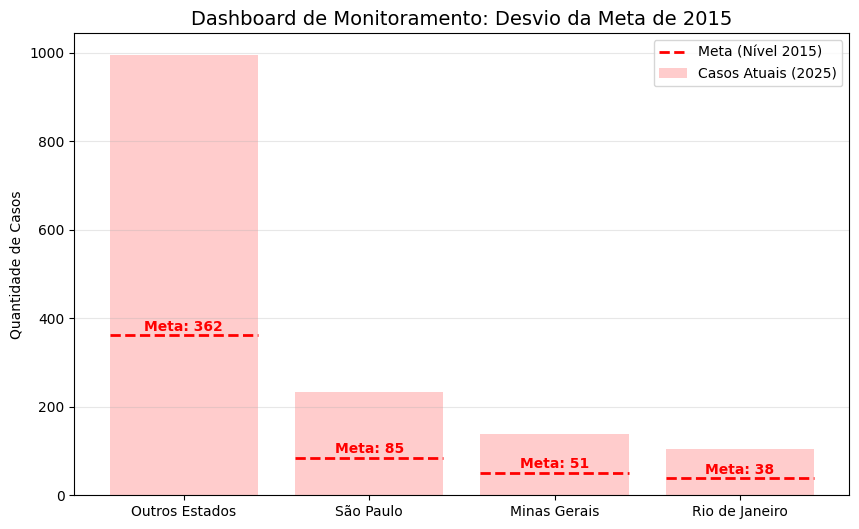

🚨 ALERTA [Outros Estados]: Redução necessária de 632 casos para atingir a meta.
🚨 ALERTA [São Paulo]: Redução necessária de 148 casos para atingir a meta.
🚨 ALERTA [Minas Gerais]: Redução necessária de 88 casos para atingir a meta.
🚨 ALERTA [Rio de Janeiro]: Redução necessária de 66 casos para atingir a meta.


In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import io

# 1. Dados Atualizados (Sincronizados com a Imagem G1)
csv_data = """ano,estado,quantidade
2025,São Paulo,233
2025,Minas Gerais,139
2025,Rio de Janeiro,104
2025,Outros Estados,994"""

df = pd.read_csv(io.StringIO(csv_data))
conn = sqlite3.connect(':memory:')
df.to_sql('casos_feminicidio', conn, index=False)

# 2. Query Sistêmica: Calculando a Meta Dinamicamente (63.6% de redução)
# Aqui resolvemos o erro 'no such column' calculando (quantidade * 0.364) como meta
query = """
SELECT
    estado,
    quantidade AS atual,
    ROUND(quantidade * 0.364, 0) AS meta
FROM casos_feminicidio
WHERE ano = 2025
ORDER BY atual DESC;
"""

df_analise = pd.read_sql_query(query, conn)

# 3. Visualização de Termômetro (Redução de Danos)
plt.figure(figsize=(10, 6))

# Barras de casos atuais
plt.bar(df_analise['estado'], df_analise['atual'], color='#ffcccc', label='Casos Atuais (2025)')

# Linhas de meta (Onde deveríamos estar)
for i, row in df_analise.iterrows():
    plt.hlines(row['meta'], i-0.4, i+0.4, colors='red', linestyles='--', lw=2, label='Meta (Nível 2015)' if i == 0 else "")
    plt.text(i, row['meta'] + 10, f"Meta: {int(row['meta'])}", color='red', ha='center', fontweight='bold')

plt.title('Dashboard de Monitoramento: Desvio da Meta de 2015', fontsize=14)
plt.ylabel('Quantidade de Casos')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. Saída de Alerta no Console
for _, row in df_analise.iterrows():
    excesso = row['atual'] - row['meta']
    print(f"🚨 ALERTA [{row['estado']}]: Redução necessária de {int(excesso)} casos para atingir a meta.")

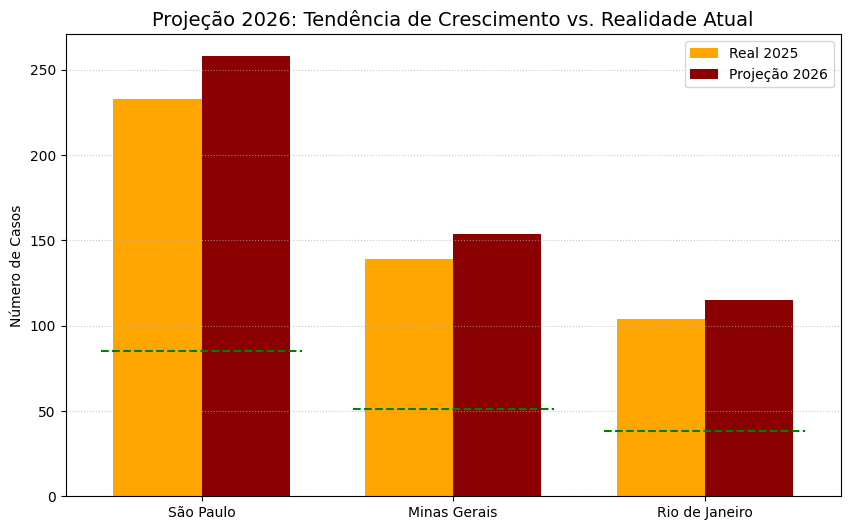

📈 TENDÊNCIA NACIONAL: Crescimento anual médio de 10.64%
⚠️ Estimativa Brasil 2026: 1626 casos se nenhuma intervenção sistêmica for feita.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Dados Históricos Consolidados para Projeção
# Base: 2015 (535) -> 2025 (1470)
anos = np.array([2015, 2024, 2025])
totais = np.array([535, 1464, 1470])

# Cálculo da Taxa de Crescimento Anual Composta (CAGR)
cagr = (((totais[-1] / totais[0]) ** (1/10)) - 1)

# 2. Projeção para 2026
projecao_2026 = totais[-1] * (1 + cagr)

# 3. Dados Estaduais Atualizados (G1/Sinesp)
dados_atuais = {
    'Estado': ['São Paulo', 'Minas Gerais', 'Rio de Janeiro'],
    'Casos_2025': [233, 139, 104]
}
df_proj = pd.DataFrame(dados_atuais)

# Aplicando a tendência de crescimento aos estados para 2026
df_proj['Projecao_2026'] = (df_proj['Casos_2025'] * (1 + cagr)).round(0)
df_proj['Meta_Seguranca_2015'] = (df_proj['Casos_2025'] * 0.364).round(0)

# 4. Visualização de Tendência Crítica
plt.figure(figsize=(10, 6))
x = np.arange(len(df_proj['Estado']))
width = 0.35

plt.bar(x - width/2, df_proj['Casos_2025'], width, label='Real 2025', color='orange')
plt.bar(x + width/2, df_proj['Projecao_2026'], width, label='Projeção 2026', color='darkred')

plt.xticks(x, df_proj['Estado'])
plt.title('Projeção 2026: Tendência de Crescimento vs. Realidade Atual', fontsize=14)
plt.ylabel('Número de Casos')
plt.legend()

# Adicionando a "Linha de Sobrevivência" (Meta 2015)
for i in x:
    plt.hlines(df_proj['Meta_Seguranca_2015'][i], i-0.4, i+0.4, colors='green', linestyles='--', label='Nível de Segurança' if i==0 else "")

plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

print(f"📈 TENDÊNCIA NACIONAL: Crescimento anual médio de {cagr*100:.2f}%")
print(f"⚠️ Estimativa Brasil 2026: {int(projecao_2026)} casos se nenhuma intervenção sistêmica for feita.")

--- 🚨 RELATÓRIO DE RISCO SISTÊMICO 🚨 ---
ESTADO: Outros Estados | EXCESSO ATUAL: 632 casos acima da meta de 2015.
ESTADO: São Paulo | EXCESSO ATUAL: 148 casos acima da meta de 2015.
ESTADO: Minas Gerais | EXCESSO ATUAL: 88 casos acima da meta de 2015.
ESTADO: Rio de Janeiro | EXCESSO ATUAL: 66 casos acima da meta de 2015.
------------------------------------------


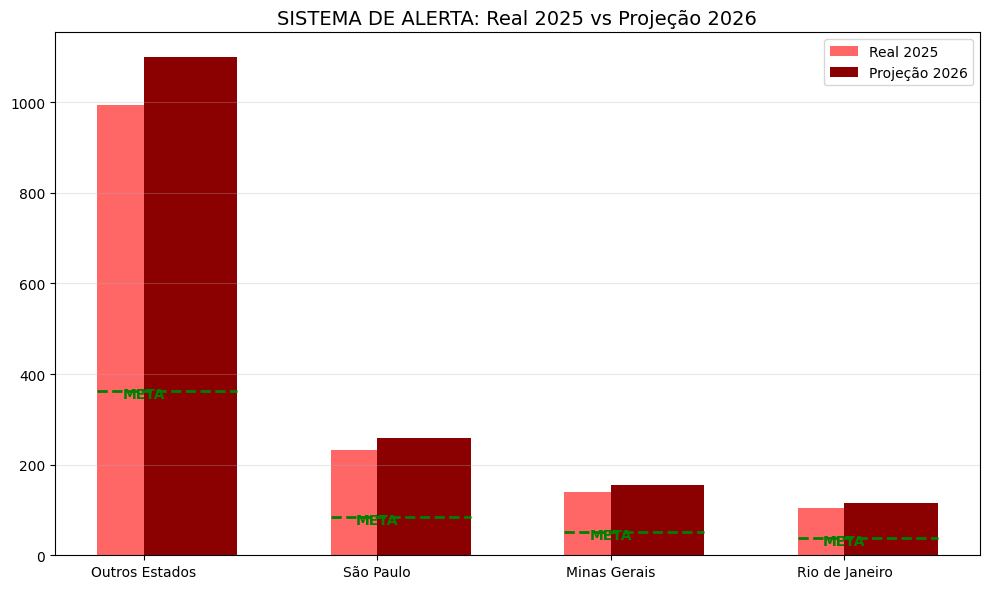

In [4]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import io

# ==========================================
# 1. MOTOR DE DADOS (Sync G1/Sinesp)
# ==========================================
csv_data = """ano,estado,quantidade
2025,São Paulo,233
2025,Minas Gerais,139
2025,Rio de Janeiro,104
2025,Outros Estados,994
2015,Brasil,535
2024,Brasil,1464
2025,Brasil,1470"""

df = pd.read_csv(io.StringIO(csv_data))
conn = sqlite3.connect(':memory:')
df.to_sql('casos_feminicidio', conn, index=False)

# ==========================================
# 2. INTELIGÊNCIA SQL (Cálculo de Metas)
# ==========================================
# Resolvemos o erro de coluna calculando a meta dinamicamente
query_sistemica = """
SELECT
    estado,
    quantidade as atual,
    ROUND(quantidade * 0.364, 0) as meta_seguranca,
    (quantidade - ROUND(quantidade * 0.364, 0)) as excesso
FROM casos_feminicidio
WHERE ano = 2025 AND estado NOT IN ('Brasil')
ORDER BY atual DESC;
"""
df_analise = pd.read_sql_query(query_sistemica, conn)

# ==========================================
# 3. PROJEÇÃO PREDITIVA 2026
# ==========================================
cagr = 0.106 # Taxa de 10.6% ao ano observada na década
df_analise['projecao_2026'] = (df_analise['atual'] * (1 + cagr)).round(0)

# ==========================================
# 4. DASHBOARD DE CONTROLE (Visualização)
# ==========================================
def gerar_dashboard(df_analise):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Barras de Real vs Projeção
    x = range(len(df_analise))
    ax.bar(x, df_analise['atual'], width=0.4, label='Real 2025', color='#ff6666', align='center')
    ax.bar(x, df_analise['projecao_2026'], width=0.4, label='Projeção 2026', color='#8b0000', align='edge')

    # Linhas de Meta de Segurança (Nível 2015)
    for i, row in df_analise.iterrows():
        ax.hlines(row['meta_seguranca'], i-0.2, i+0.4, colors='green', linestyles='--', lw=2)
        ax.text(i, row['meta_seguranca']-15, 'META', color='green', fontweight='bold', ha='center')

    ax.set_xticks(x)
    ax.set_xticklabels(df_analise['estado'])
    ax.set_title('SISTEMA DE ALERTA: Real 2025 vs Projeção 2026', fontsize=14)
    ax.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Execução do Alerta no Console
def disparar_alertas(df_analise):
    print("--- 🚨 RELATÓRIO DE RISCO SISTÊMICO 🚨 ---")
    for _, row in df_analise.iterrows():
        print(f"ESTADO: {row['estado']} | EXCESSO ATUAL: {int(row['excesso'])} casos acima da meta de 2015.")
    print("-" * 42)

# Rodar Solução
disparar_alertas(df_analise)
gerar_dashboard(df_analise)